In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 200

# 1. Features
# Age: Between 10 and 60
age = np.random.randint(10, 60, n)
# Income: Between 0 and 10,000 TL
income = np.random.randint(0, 10000, n)
# 2. Target (Is Premium Member?)
# Rules:
# - RULE 1: If under 18 -> Usually No (0)
# - RULE 2: If over 18 AND Income is more than 5000 -> Yes (1)
# - RULE 3: If over 18 AND Income is less than 5000 -> No (0)

premium = []
for y, g in zip(age, income):
    if y < 18:
        # Children usually do not buy (%10 exception/noise added)
        premium.append(1 if np.random.random() < 0.1 else 0)
    else:
        if g > 5000:
            # Wealthy adults usually buy (%90 probability)
            premium.append(1 if np.random.random() < 0.9 else 0)
        else:
            # Low-income adults usually do not buy
            premium.append(0)

df_tree = pd.DataFrame({'Age': age, 'Income': income, 'Premium': premium})

print(df_tree.head(10))

   Age  Income  Premium
0   48    1998        0
1   38    7994        1
2   24    1495        0
3   52    3304        0
4   17    3763        0
5   30    5232        1
6   48    1853        0
7   28    6585        1
8   32    1291        0
9   20    3581        0


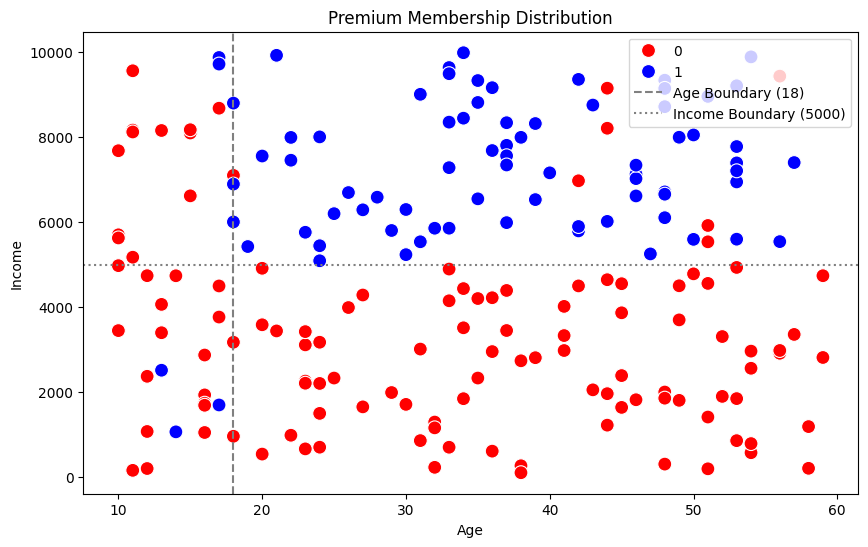

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Income', hue='Premium', data=df_tree, palette=['red', 'blue'], s=100)
# Let's draw the critical boundaries as imaginary lines
plt.axvline(x=18, color='gray', linestyle='--', label='Age Boundary (18)')
plt.axhline(y=5000, color='gray', linestyle=':', label='Income Boundary (5000)')

plt.title('Premium Membership Distribution')
plt.legend()
plt.show()

In [3]:
X = df_tree[['Age', 'Income']]
y = df_tree['Premium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the model (Allow maximum depth of 3)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

print("Decision Tree Model Trained.")

Decision Tree Model Trained.


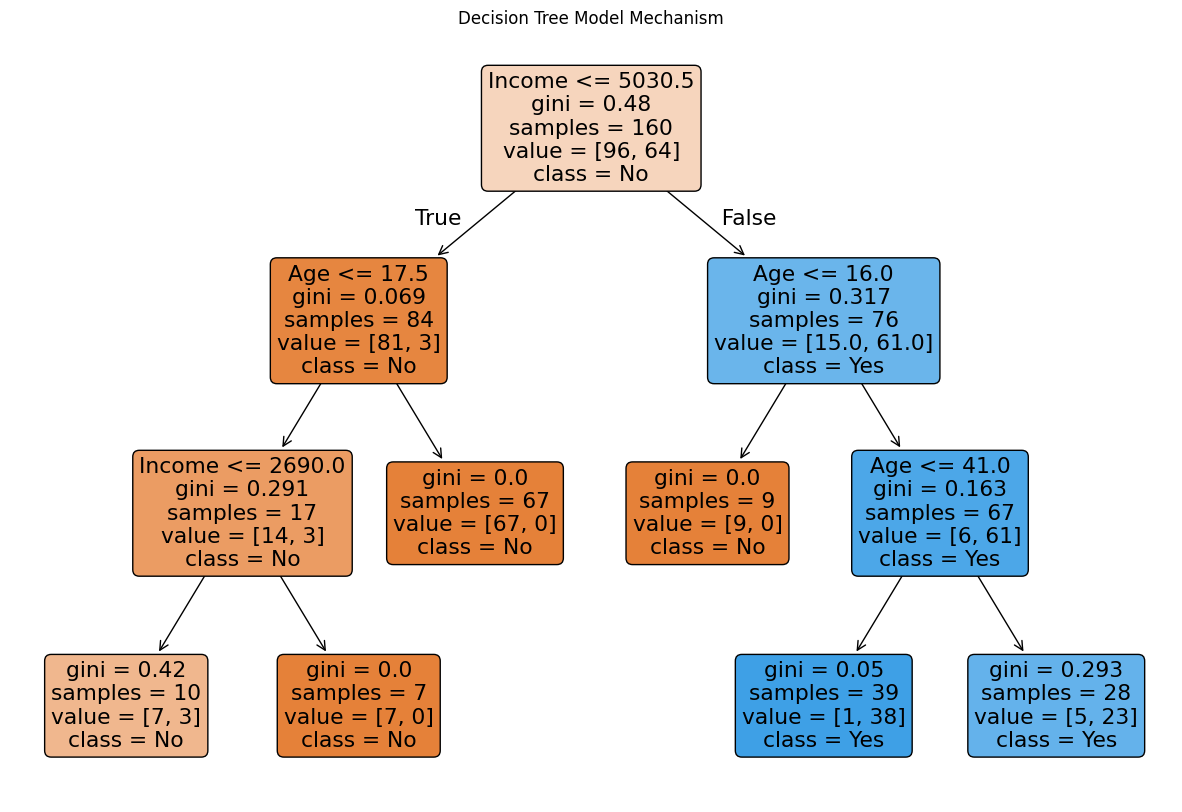

In [4]:
plt.figure(figsize=(15, 10))
plot_tree(tree_model, 
          feature_names=['Age', 'Income'], 
          class_names=['No', 'Yes'], 
          filled=True, 
          rounded=True)
plt.title("Decision Tree Model Mechanism")
plt.show()

<Figure size 1000x600 with 0 Axes>

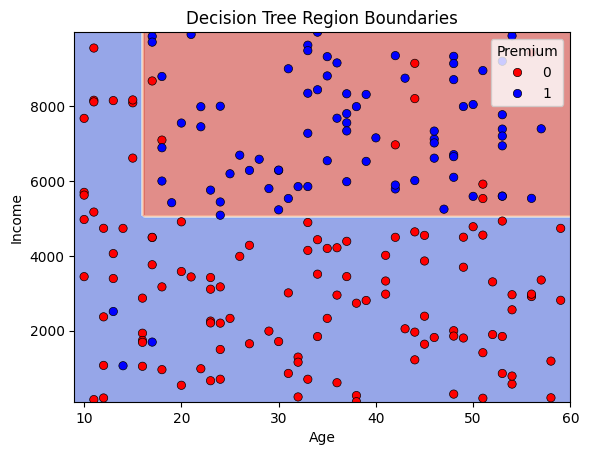

In [5]:
from sklearn.inspection import DecisionBoundaryDisplay

plt.figure(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(
    tree_model, 
    X, 
    cmap='coolwarm', 
    response_method='predict',
    alpha=0.6
)

# Let's plot the actual points on top
sns.scatterplot(x='Age', y='Income', hue='Premium', data=df_tree, palette=['red', 'blue'], edgecolor='black')
plt.title('Decision Tree Region Boundaries')
plt.show()

In [6]:
# Predictions and Accuracy
y_pred = tree_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: %{acc * 100:.2f}")

# Example Customer Scenarios
# 1. Customer: 16 years old, Father is wealthy (Income 8000) -> Should be limited by age rule
# 2. Customer: 35 years old, Income 7000 -> Should buy
examples = [[16, 8000], [35, 7000]]
predictions = tree_model.predict(examples)

print(f"Does the 16-year-old customer buy? {'Yes' if predictions[0]==1 else 'No'}")
print(f"Does the 35-year-old customer buy? {'Yes' if predictions[1]==1 else 'No'}")

Model Accuracy: %95.00
Does the 16-year-old customer buy? No
Does the 35-year-old customer buy? Yes
